# Baselines and ALS tuning

Every number here comes from `reports/metrics/*.json`, written by the DVC stages
`baselines` and `als_search` (`make experiments`). All models are trained on the logged feed
before Aug 30 and evaluated on the fully observed **tune** users: each user's whole candidate
list is ranked, metrics are computed per user and then averaged, with 95% bootstrap intervals.
The same runs are in MLflow (`make mlflow-ui`) and W&B (offline under `wandb/`).

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import polars as pl

from recsys.viz import style


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "dvc.yaml").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository")


ROOT = find_repo_root(Path.cwd())
METRICS, FIGURES = ROOT / "reports/metrics", ROOT / "reports/figures"
baselines = json.loads((METRICS / "baselines.json").read_text(encoding="utf-8"))
search = json.loads((METRICS / "als_search.json").read_text(encoding="utf-8"))
METRIC = search["select_metric"]
style.apply_style()


def save(fig: plt.Figure, name: str) -> None:
    fig.savefig(FIGURES / f"{name}.png")
    plt.show()
    plt.close(fig)

## 1. Leaderboard (tune users: the same users that selected ALS's settings)

In [2]:
leaderboard = pl.DataFrame(
    [
        {
            "model": name,
            METRIC: m[METRIC],
            "95% CI": f"{m[f'{METRIC}_ci_low']:.3f} – {m[f'{METRIC}_ci_high']:.3f}",
            "precision_at_10": m["precision_at_10"],
            "coverage_at_10": m["coverage_at_10"],
            "gini_at_10": m["gini_at_10"],
            "popularity_pct_at_10": m["popularity_pct_at_10"],
        }
        for name, m in baselines["models"].items()
    ]
).sort(METRIC, descending=True)
leaderboard

model,ndcg_at_10,95% CI,precision_at_10,coverage_at_10,gini_at_10,popularity_pct_at_10
str,f64,str,f64,f64,f64,f64
"""als""",0.274005,"""0.246 – 0.302""",0.269231,0.223625,0.903708,0.805465
"""popularity_engagement""",0.217004,"""0.195 – 0.240""",0.214047,0.003306,0.996984,0.656027
"""popularity_views""",0.183764,"""0.162 – 0.206""",0.173913,0.003306,0.996994,0.998646
"""random""",0.163518,"""0.143 – 0.185""",0.161873,0.592125,0.544809,0.503529


## 2. Paired comparison with the strongest non-personalized baseline

Confidence intervals of two models computed separately overlap a lot, because much of the
spread is each user's own base rate of positives. Comparing models on the same users removes
that shared variance (the same idea as paired designs in A/B tests). The intervals cover
*user sampling* only: they are conditional on the candidate videos, the label cut-offs and each
model's seed. The win rate shows how evenly a gain is spread across users.

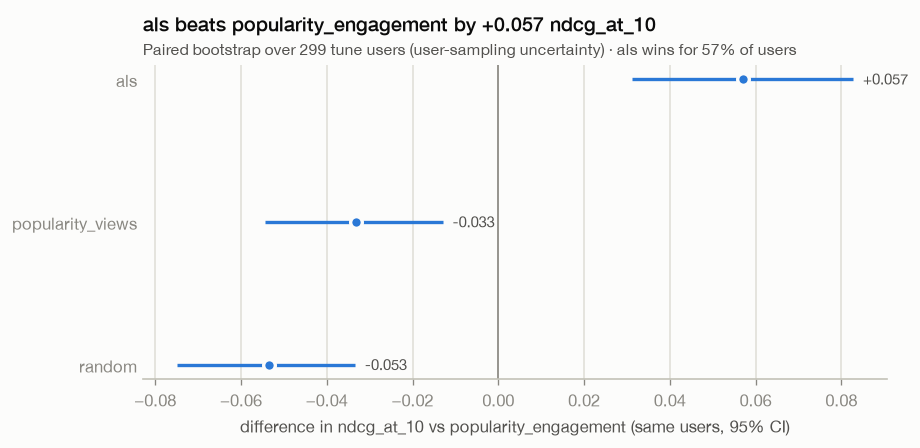

In [3]:
paired = baselines["paired_vs_reference"]
differences = pl.DataFrame(
    [{"model": name, **values} for name, values in paired["differences"].items()]
).sort("mean")

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.axvline(0, color=style.INK_MUTED, linewidth=1)
positions = range(differences.height)
ax.errorbar(
    differences["mean"],
    positions,
    xerr=[
        differences["mean"] - differences["ci_low"],
        differences["ci_high"] - differences["mean"],
    ],
    fmt="o",
    color=style.PRIMARY,
    ecolor=style.PRIMARY,
    elinewidth=2,
    capsize=0,
    markersize=7,
    markeredgecolor=style.SURFACE,
    markeredgewidth=2,
)
for position, row in zip(positions, differences.iter_rows(named=True), strict=True):
    ax.annotate(
        f"{row['mean']:+.3f}",
        (row["ci_high"], position),
        xytext=(6, 0),
        textcoords="offset points",
        va="center",
        color=style.INK_SECONDARY,
        fontsize=9,
    )
ax.set_yticks(list(positions), differences["model"].to_list())
ax.tick_params(axis="y", length=0)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.set_xlabel(f"difference in {METRIC} vs {paired['reference']} (same users, 95% CI)")
best = differences.row(-1, named=True)
style.add_title(
    ax,
    f"{best['model']} beats {paired['reference']} by {best['mean']:+.3f} {METRIC}",
    f"Paired bootstrap over {baselines['models']['als']['users_evaluated']} tune users "
    f"(user-sampling uncertainty) · {best['model']} wins for {best['win_rate']:.0%} of users",
)
save(fig, "09_baselines_paired_comparison")

## 3. ALS tuning: accuracy vs. popularity bias

ALS uses Hu et al.'s confidence `1 + alpha * count` (alpha = 0 is the plain binary matrix).
The grid was widened until the best alpha sat inside it; the top configurations are within
0.001 of each other, so the exact pick matters little.

**Winner's curse.** The best of many trials, scored on the same users that picked it, looks
better than it is. A bootstrap over users (pick the best trial in-sample, score it on the users
left out) estimates that optimism; subtracting it gives a fairer estimate for new users. The
final, unbiased number comes from the untouched test users.

In [4]:
chosen_params = search["best"]["params"]
trials = pl.DataFrame(
    [{**trial["params"], **trial["metrics"]} for trial in search["trials"]]
).with_columns(
    chosen=(pl.col("factors") == chosen_params["factors"])
    & (pl.col("regularization") == chosen_params["regularization"])
    & (pl.col("alpha") == chosen_params["alpha"])
)
print(
    f"best {METRIC}: {search['best']['metrics'][METRIC]:.4f} · estimated selection optimism: "
    f"{search['selection_optimism']:.4f} · corrected: {search['best_score_optimism_corrected']:.4f}"
)
trials.select("factors", "regularization", "alpha", METRIC, "popularity_pct_at_10").sort(
    METRIC, descending=True
).head(5)

best ndcg_at_10: 0.2740 · estimated selection optimism: 0.0146 · corrected: 0.2594


factors,regularization,alpha,ndcg_at_10,popularity_pct_at_10
i64,f64,f64,f64,f64
64,0.1,1.0,0.274005,0.805465
16,0.1,1.0,0.273932,0.791306
64,0.3,1.0,0.273822,0.804695
64,1.0,1.0,0.273295,0.806728
16,1.0,1.0,0.272911,0.793595


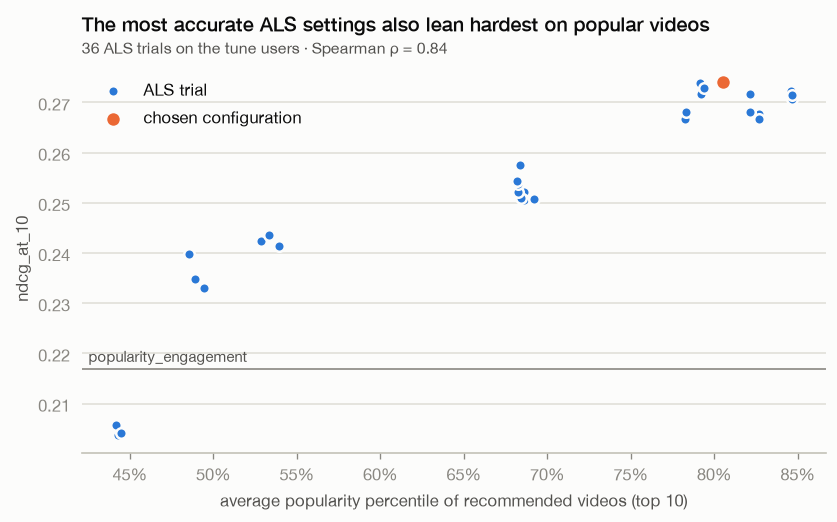

In [5]:
reference = baselines["models"][paired["reference"]]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.scatter(
    trials["popularity_pct_at_10"],
    trials[METRIC],
    s=40,
    color=style.PRIMARY,
    edgecolors=style.SURFACE,
    linewidths=1.5,
    label="ALS trial",
)
chosen = trials.filter("chosen").row(0, named=True)
ax.scatter(
    [chosen["popularity_pct_at_10"]],
    [chosen[METRIC]],
    s=90,
    color=style.SECONDARY,
    edgecolors=style.SURFACE,
    linewidths=2,
    label="chosen configuration",
    zorder=3,
)
ax.axhline(reference[METRIC], color=style.INK_MUTED, linewidth=1)
ax.annotate(
    paired["reference"],
    (0, reference[METRIC]),
    xycoords=("axes fraction", "data"),
    xytext=(4, 4),
    textcoords="offset points",
    color=style.INK_SECONDARY,
    fontsize=9,
)
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax.set_xlabel("average popularity percentile of recommended videos (top 10)")
ax.set_ylabel(METRIC)
ax.legend(loc="upper left")
style.add_title(
    ax,
    "The most accurate ALS settings also lean hardest on popular videos",
    f"{trials.height} ALS trials on the tune users · Spearman ρ = "
    f"{trials.select(pl.corr('popularity_pct_at_10', METRIC, method='spearman')).item():.2f}",
)
save(fig, "10_als_accuracy_vs_popularity")